In [45]:

df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number_02', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).orderBy(F.col('linea_sae').desc())

df_dni = df_filtrado.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'sae_202603241734.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [6]:
filename='Lista Excepcion 20260324 - Target.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

# -----------------------------------

query = """
  select * from cronox.dbo.borrar_df_efe_ng_01
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


# ------------------------------------------


['DNI']


In [10]:
df_prueba = df_prueba.withColumn(
    "DNI",
    F.right(F.lpad(F.col("DNI").cast("string"), 8, "0"), F.lit(8))
)
df_prueba=df_prueba.withColumnRenamed('DNI','vendor_lead_code')

In [11]:
print(df_prueba.columns)

['vendor_lead_code']


In [17]:
df_prueba.count()

526

In [20]:
df_list.join(df_prueba,['vendor_lead_code'],'leftanti').count()


445662

In [27]:
df_list.count()

0

In [17]:
query = """
  select * from cronox.dbo.borrar_df_efe_ng_03
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_list=df_list.join(df_prueba,['vendor_lead_code'],'leftanti')

# query = """
#   select * from cronox.dbo.borrar_df_efe_cm_02
#     """
# df_list2 = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# df_list2=df_list2.join(df_prueba,['vendor_lead_code'],'leftanti')
df_list.count()

445662

In [18]:
overwrite_table_SQL(spark,df_list,'borrar_df_efe_ng_01',server_sa,user_sa,pwd_sa,'CRONOX')


In [16]:
overwrite_table_SQL(spark,df_list2,'borrar_df_efe_CM_01',server_sa,user_sa,pwd_sa,'CRONOX')


In [24]:
df_list2.count()

0

In [27]:
print(df_list.columns)

['vendor_lead_code', 'phone_number', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_telf', 'mejor15_CODIGO_cli', 'mejor_CODIGO_cli', 'indice_num', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'min_numero', 'phone_number_04', 'deuda', 'tip_prioridad', 'Zona', 'perfil_ic', 'canal_asignado', 'MARCA', 'FECHA_ENVIO', 'region', 'prioridada', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf',

In [28]:

df_prueba = df_prueba.withColumn(
    "NUMDOCUMENTO",
    F.right(F.lpad(F.col("NUMDOCUMENTO").cast("string"), 8, "0"), F.lit(8))
)
df_prueba = df_prueba.filter(
    (F.col("CELULAR1").rlike(r"^[0-9]+$")) &
    (F.col("CELULAR1").startswith("9")) &
    (F.length(F.col("CELULAR1")) == 9)
)
df_prueba=df_prueba.withColumnRenamed('NUMDOCUMENTO','vendor_lead_code')
df_prueba=df_prueba.withColumnRenamed('CELULAR1','TELEFONO__1')
df_list=df_list.join(df_prueba,['vendor_lead_code'],'inner')

df_list = df_list.withColumn(
    "phone_number",
    F.col("TELEFONO__1")
).drop("TELEFONO__1")

df_list = df_list.dropDuplicates(
    ["vendor_lead_code", "phone_number"]
)

df_list=df_list.select('vendor_lead_code', 'phone_number', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments')
df_list.count()

27421

In [ ]:

df_prueba = df_prueba.withColumn(
    "NUMDOCUMENTO",
    F.right(F.lpad(F.col("NUMDOCUMENTO").cast("string"), 8, "0"), F.lit(8))
)
df_prueba = df_prueba.filter(
    (F.col("CELULAR1").rlike(r"^[0-9]+$")) &
    (F.col("CELULAR1").startswith("9")) &
    (F.length(F.col("CELULAR1")) == 9)
)
df_prueba=df_prueba.withColumnRenamed('NUMDOCUMENTO','vendor_lead_code')
df_prueba=df_prueba.withColumnRenamed('CELULAR1','TELEFONO__1')
df_list=df_list.join(df_prueba,['vendor_lead_code'],'inner')

df_list = df_list.withColumn(
    "phone_number",
    F.col("TELEFONO__1")
).drop("TELEFONO__1")

df_list = df_list.dropDuplicates(
    ["vendor_lead_code", "phone_number"]
)

df_list=df_list.select('vendor_lead_code', 'phone_number', 'first_name', 'last_name', 'address1', 'address3', 'city', 'province', 'email', 'comments')
df_list.count()


# ---------------------------
df_final = df_list.toPandas()
print('listo')
df_final.to_excel('base_seguimiento_reingreso_2403.xlsx', index=False)

listo


In [ ]:
efec_negocio.count()

In [41]:
def vicidial():
    fecha_mes_base='2026-03-01'
    ls_una_vez = ['AB','ADC','ADCT','B036','B037','B038']
    ls_ocupado = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']
    ls_casilla = ['no_hay_nada']
    tipi_cond1='EFECTIVA_NC'
    tipi_cond2='xx'
    tipi_tb='tTipologia_Efectiva'
    servidor_01=7
    tipi_cod='Codigo'
    tipi_resp_cod='B'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO CONTACTO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroEfectiva'
    tnum_dni='DNI'
    tlista_generada='borrar_df_efe_consumo_01'

    return since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)


In [42]:
efec_negocio=vicidial()

In [43]:

efec_negocio=efec_negocio.select('vendor_lead_code', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'PESO', 'phone_number', 'CODIGO', 'n_mejor_resul','dni_ejecutivo', 'ejecutivo', 'q_intentos_telef', 'DESCRIPCION', 'dial_method').filter(col('CODIGO').isin('B002','B004','B023'))
efec_negocio.count()


3246

In [44]:

df = efec_negocio.toPandas()
df.to_excel('vicidial_marzo_consumo.xlsx', index=False)
print('listo')

listo


In [13]:
df_vicidial=since_vicidial(spark,fecha_mes_base,'SAE','SAR','tTipologia_Cencosud_PPFF',76,'Codigo','R','DESCRIPCION','TIPO','NO GESTIONADO')


In [14]:
df_vicidial.filter((col('phone_number')=='999376331')
&(col('fecha_llamada')=='2026-03-23')
).orderBy(col('fecha_llamada').desc()).show()

+----------------+--------------+--------------+-------------------+--------+-----------+----------------+------------+--------------------+-------------+-----+----------------+----+------------+------+-------------+--------------------+-----------+-------------+--------------------+----------------+---------------+--------------------+
|vendor_lead_code|numero_campana|nombre_campana| fecha_hora_llamada|duracion|call_result|       list_name|fecha_agenda|         comentarios|fecha_llamada|tramo|mejor_CODIGO_cli|PESO|phone_number|CODIGO|n_mejor_resul|mejor_CODIGO_cli_dia|cod_attempt|dni_ejecutivo|           ejecutivo|q_intentos_telef|    DESCRIPCION|         dial_method|
+----------------+--------------+--------------+-------------------+--------+-----------+----------------+------------+--------------------+-------------+-----+----------------+----+------------+------+-------------+--------------------+-----------+-------------+--------------------+----------------+---------------+-----

In [2]:
def list02_cenco_pp():
    fecha_mes_base='2026-03-01'
    ls_una_vez = ['R016','R019','DC']
    ls_ocupado = ['R017','AB']
    ls_casilla = ['R018','AA']
    tipi_cond1='SAE'
    tipi_cond2='SAR'
    tipi_tb='tTipologia_Cencosud_PPFF'
    servidor_01=76
    tipi_cod='Codigo'
    tipi_resp_cod='R'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO GESTIONADO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroCenco_Sae'
    tnum_dni='CODDOC'
    tlista_generada='borrar_df_cencosud_pp_01'
    get_base=since_base_maestra_cencosud_ppff

    lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)

def list02_cenco_tc():
    fecha_mes_base='2026-03-01'
    ls_una_vez = ['R016','R019','DC']
    ls_ocupado = ['R017','AB']
    ls_casilla = ['R018','AA']
    tipi_cond1='CENCOSUD_TC'
    tipi_cond2='xx'
    tipi_tb='tTipologia_Cencosud_TC'
    servidor_01=76
    tipi_cod='Codigo'
    tipi_resp_cod='R'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO GESTIONADO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroCenco_Tc'
    tnum_dni='CODDOC'
    tlista_generada='borrar_df_cencosud_tc_01'
    get_base=since_base_maestra_cencosud_tc

    lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)

def list02_efe_consumo():
    fecha_mes_base='2026-03-01'
    ls_una_vez = ['AB','ADC','ADCT','B036','B037','B038']
    ls_ocupado = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']
    ls_casilla = ['no_hay_nada']
    tipi_cond1='EFECTIVA_NC'
    tipi_cond2='xx'
    tipi_tb='tTipologia_Efectiva'
    servidor_01=7
    tipi_cod='Codigo'
    tipi_resp_cod='B'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO CONTACTO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroEfectiva'
    tnum_dni='DNI'
    tlista_generada='borrar_df_efe_consumo_01'
    get_base=since_base_maestra_efe_consumo
    lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)

def list02_efe_negocios():
    fecha_mes_base='2026-03-01'
    ls_una_vez = ['AB','ADC','ADCT','B036','B037','B038']
    ls_ocupado = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']
    ls_casilla = ['no_hay_nada']
    tipi_cond1='EFECTIVA_NEGOCIOS'
    tipi_cond2='xx'
    tipi_tb='tTipologia_Efectiva'
    servidor_01=64
    tipi_cod='Codigo'
    tipi_resp_cod='B'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO CONTACTO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroEfectivaNegocios'
    tnum_dni='NUMDOCUMENTO'
    tlista_generada='borrar_df_efe_negocio_01'
    get_base=since_base_maestra_efe_negocio

    lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)

def list02_dinners():
    fecha_mes_base='2026-03-01'
    ls_una_vez = ['AB','ADC','ADCT','B036','B037','B038']
    ls_ocupado = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']
    ls_casilla = ['no_hay_nada']
    tipi_cond1='EFECTIVA_NC'
    tipi_cond2='xx'
    tipi_tb='tTipologia_Efectiva'
    servidor_01=7
    tipi_cod='Codigo'
    tipi_resp_cod='B'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO CONTACTO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroEfectivaNegocios'
    tnum_dni='NUMDOCUMENTO'
    tlista_generada='borrar_df_efe_cm_01'
    lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada)



In [28]:
def solicitud(spark,dir_1,coincidencia1,coincidencia2,fecha_mes_base_1,fecha_mes_base):
    fecha_mes_base_1='2026-01-01'
    query = f"""
        SELECT *
        FROM OPENQUERY([192.168.3.{dir_1}], '
            SELECT        
            rtrim(ltrim(d.vendor_lead_code)) AS vendor_lead_code,        
            e.dial_method,
            a.campaign_id AS numero_campana,        
            a.user AS dni_ejecutivo,
            c.full_name AS ejecutivo,
            e.campaign_name AS nombre_campana,        
            a.call_date AS fecha_hora_llamada,        
            a.length_in_sec AS duracion,        
            b.status_name AS call_result,        
            f.list_description,        
            f.list_name,        
            a.phone_number as phone_number,        
            d.alt_phone as fecha_agenda,        
            d.comments as comentarios,        
            a.status AS CODIGO
            FROM asterisk.vicidial_log a         
            LEFT JOIN asterisk.vicidial_list d ON a.lead_id=d.lead_id        
            LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id=e.campaign_id        
            LEFT JOIN asterisk.vicidial_lists f ON a.list_id=f.list_id        
            LEFT JOIN asterisk.vicidial_statuses b ON a.status=b.status        
            LEFT JOIN asterisk.vicidial_users c ON a.user=c.user        
            WHERE (e.campaign_name like "%{coincidencia1}" or e.campaign_name like "%{coincidencia2}")
            AND a.call_date >= DATE_FORMAT(''{fecha_mes_base_1}'', ''%Y-%m-01'')
            AND a.call_date < DATE_ADD(DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''), INTERVAL 1 MONTH)
            and a.phone_number=''945308605''

        ')

        """
    return obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

## GENERAR LISTAS

In [9]:
# list02_cenco_pp()
# list02_cenco_tc()
list02_efe_negocios()
# list02_efe_consumo()

tabla borrar_df_efe_negocio_01 actualizada


In [ ]:

fecha_mes_base='2026-03-01'

ls_una_vez = ['H035','','DC']
ls_ocupado = ['H037']
ls_casilla = ['xxxxx']

tipi_cond1='DINERS TC'
tipi_cond2='xx'
tipi_tb='tTipologia_Diners_TC'
servidor_01=21
tipi_cod='cod'
tipi_resp_cod='h'
tipi_descrip='[NIVEL 4]'
tipi_estado='[NIVEL 2]'
tipi_resp_estado='NO CONTACTO'
tipi_subdescripcion='[NIVEL 3]'
tnum_tb='tNumeroDinersTc'
tnum_dni='NUMERO_DOCUMENTO'
tlista_generada='borrar_df_dinners_tc_01'
get_base=since_base_maestra_dinners_tc

lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)

In [25]:
spark.stop()

In [14]:
lista = [row['seg_linea_hs_plus'] for row in df_base.select('seg_linea_hs_plus').distinct().collect()]
print(lista)

['p. [25000,+)', 'n. [16000,20000)', 'j. [9000,10000)', 'i. [8000,9000)', 'l. [12000,15000)', 'a. [0,1000)', 'h. [7000,8000)', 'e. [4000,5000)', 'o. [20000,25000)', 'd. [3000,4000)', 'g. [6000,7000)', 'f. [5000,6000)', 'z. otros', 'c. [2000,3000)', 'b. [1000,2000)', 'k. [10000,12000)', 'm. [15000,16000)']


In [ ]:
df_vicidial=since_vicidial(spark,fecha_mes_base,'EFECTIVA_NC','XXXXXX','tTipologia_Efectiva',7,'codigo','B','descripcion','tipo','NO CONTACTO')


In [48]:
df_a=since_base_maestra_efe_consumo(spark)

In [ ]:
df_base.select('score').distinct().show()

In [ ]:

list_una_vez_cenco = ['R016','R019','DC']
list_una_vez_efe=['AB','ADC','ADCT','B036','B037','B038']

list_ocupado_cenco = ['R017']
list_ocupado_efe = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']

list_casilla_cenco = ['R018','AA']
list_casilla_efe = []


In [ ]:
codigo_tipi=cenco['PDROP', 'R018', 'R014', 'AA', 'R007', 'R005', 'NA', 'R017', 'R001', 'DROP', 'R010', 'R004', 'R013', 'R019', 'AB', 'R003', 'CALLBK', 'R016', 'R015', 'R009', 'R002', 'R012', 'R006', None]

no_relanzable_cenco=['R001','R003','R015','R012','R002','R002','R002','R002','R002']

list_cet=['R004','R001','R002','R003','R005','R006','R007','R008','R009','R010','R011','R012','R013','CALLBK']
list_no_cet=['R014','R015','R016']
list_no_contacto['R017','R018','R019']
list_no_gestionado['AA','AB','ADC','B','DC','DISPO','DONEM','DROP','INCALL','NA','PDROP','QUEUE']

no_relanzable_consumo=['B014','B001','B002','B006','B003','B005','B017','B018','B021','B023','B025','B026','B041','B040','B020','B019']



In [101]:
query=f'''
    SELECT Codigo as mejor_CODIGO_cli ,
TIPO AS mejor_estado_tipi_cli,
DESCRIPCION as mejor_descripcion_cli ,
SUB_DESCRIPCION as mejor_sub_descripcion,
PESO as mejor_peso_cli  
FROM [ODIN].[dbo].tTipologia_Cencosud_TC
where (LEFT(Codigo,1)='R' or TIPO='NO GESTIONADO' or Codigo='CALLBK')
and TIPO<>'CONTACTO EFECTIVO'

'''
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [102]:
df_list_cencosud.select('mejor_estado_tipi_cli').distinct().show(truncate=False)

+---------------------+
|mejor_estado_tipi_cli|
+---------------------+
|CONTACTO NO EFECTIVO |
|NO CONTACTO          |
|NO GESTIONADO        |
+---------------------+



In [98]:
(df_list_cencosud 
    .select('mejor_estado_tipi_cli','mejor_CODIGO_cli','mejor_descripcion_cli') 
    .distinct() 
    .show(20,truncate=False))


+---------------------+----------------+---------------------------------------+
|mejor_estado_tipi_cli|mejor_CODIGO_cli|mejor_descripcion_cli                  |
+---------------------+----------------+---------------------------------------+
|CONTACTO EFECTIVO    |R003            |VOLVER A LLAMAR                        |
|CONTACTO EFECTIVO    |R004            |DESEA IR A AGENCIA                     |
|CONTACTO EFECTIVO    |CALLBK          |VOLVER A LLAMAR                        |
|CONTACTO EFECTIVO    |R010            |NO DESEA –NO ESPECIFICA MOTIVO         |
|CONTACTO EFECTIVO    |R006            |OFERTA DE LINEA MUY BAJA               |
|CONTACTO EFECTIVO    |R002            |ZONA FUERA DE COBERTURA                |
|CONTACTO EFECTIVO    |R013            |CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA|
|CONTACTO EFECTIVO    |R011            |NO AUTORIZA CONTINUAR CON LA LLAMADA   |
|CONTACTO EFECTIVO    |R007            |CLIENTE DESEA OTRO PRODUCTO            |
|CONTACTO EFECTIVO    |R009 

In [ ]:
list_cet=[]

In [54]:
fecha_mes_base='2026-03-01'

In [ ]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=tu_servidor;"
    "DATABASE=CRONOX;"
    "UID=tu_usuario;"
    "PWD=tu_password;"
)

cursor = conn.cursor()

# Ejecutar el stored procedure
cursor.execute("EXEC dbo.SP_Generador_CENCOSUD_SAE")

# Confirmar cambios (MUY IMPORTANTE)
conn.commit()

cursor.close()
conn.close()

print("Stored Procedure ejecutado correctamente")

In [48]:
query=f'''
    select distinct CODDOC
    from ODIN.dbo.Base_Maestra_Cencosud_PPFF_Vigente 
'''
df_vigente_zeus = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_vigente_zeus.count()

38603

In [47]:
df_vigente.count()

38606

In [49]:
df_vigente=df_vigente.join(df_vigente_zeus,['CODDOC'],'leftanti')
df_vigente.count()

3

tabla borrar_df_cencosud_pp_01 actualizada


In [ ]:
dir_1=8
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{dir_1}], '
        SELECT a.*, c.tDni 
        FROM bdsae2.tb_clientes a
        JOIN bdsae2.tb_solicitud b 
            ON a.tRegistro = b.tRegistro
        JOIN bdbbva.usuario c 
            ON a.tUsuario = c.tCodigo  
        WHERE a.fFechaGrabacion >= ''{fecha_mes_base}''
        AND a.fFechaGrabacion < DATE_ADD(''{fecha_mes_base}'', INTERVAL 1 MONTH)
    ')
    """
df_crm=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

query = """
    SELECT Codigo as mejor_CODIGO_cli ,TIPO AS mejor_estado_tipi_cli
    , case
        when Codigo='CALLBK' then 'VOLVER A LLAMAR - call'
        else DESCRIPCION 
    end as mejor_descripcion_cli 
    , case
        when Codigo='CALLBK' then 'AGENDAMIENTO - call'
        else SUB_DESCRIPCION 
    end as mejor_sub_descripcion
    ,case 
        when Codigo='CALLBK' then 1200
        else PESO 
    end as mejor_peso_cli  
    FROM [ODIN].[dbo].tTipologia_Cencosud_PPFF
    where LEFT(Codigo,1)='R' or TIPO='NO GESTIONADO' or Codigo='CALLBK'

    """
df_tipi1=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

query = """
    SELECT * 
    FROM URANO.dbo.tPersonalCrm
    """
df_personas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_vicidial=since_vicidial(spark,fecha_mes_base,'SAE','SAR','tTipologia_Cencosud_PPFF',76,'Codigo','DESCRIPCION','TIPO','NO GESTIONADO')
df_vicidial=df_vicidial.select('vendor_lead_code', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'phone_number', 'CODIGO', 'dni_ejecutivo', 'ejecutivo', 'DESCRIPCION')
df_base_vigente=since_base_maestra_cencosud_ppff(spark,f'{fecha_mes_base}')
df_base_vigente=df_base_vigente.select('vendor_lead_code', 'TIPDOC')

print(df_crm.columns)
print(df_tipi1.columns)
print(df_base_vigente.columns)
print(df_vicidial.columns)
print(df_personas.columns)



In [ ]:
# df_dni=df_filtrado.select('vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments').orderBy(col('LINEA_SAE').desc()).toPandas()
df_dni=df_filtrado.toPandas()
# df_dni.to_csv(ruta_csv+'prueba.xlsx', index=False,sep=';')
import os

ruta_archivo = os.path.join(ruta_csv, 'sae_2026031316_1.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

3725

In [38]:
query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_pp_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_list_cencosud = df_list_cencosud.withColumn(
    'LINEA_SAE',
    col('LINEA_SAE').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'q_intentos_telef',
    col('q_intentos_telef').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'tea',
    col('tea').cast('double')
)

df_filtrado = df_list_cencosud.filter(
    (col('title')=='SAE') &
    ((~col('mejor_CODIGO_cli').isin(no_relanzable)) | (col('mejor_CODIGO_cli').isNull())) &
    ((~col('mejor15_CODIGO_telf').isin(no_relanzable)) | (col('mejor15_CODIGO_telf').isNull())) &
    (col('tipo_telf').isin('bbdd cel01')) &
    (
        (col('q_intentos_telef')<= 32) | (col('q_intentos_telef').isNull())
    ) &
    (
        (col('fecha_llamada') <= '2026-03-18')
        |(col('fecha_llamada').isNull())
    ) &
    (
        (
            (col('PROPENSION') == 'ALTO') &
                (col('LINEA_SAE').between(3000,10000))&
            (col('tea')> 0.60)
        )|
        (
            (col('PROPENSION') == 'MEDIO') &
                (col('LINEA_SAE').between(3000,10000))&
            (col('tea')> 0.30)
        )
    )

).orderBy(col('LINEA_SAE').desc())

df_filtrado.count()



5292

In [44]:
fecha_mes_base='2026-03-01'
t_maestra='Base_Maestra_Cencosud_PPFF'
t_name_vigente='Base_Maestra_Cencosud_PPFF_vigente'
t_mumeros='tNumeroCenco_Sae'
cols_drop=[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2']


In [45]:
generar_tb_vigente(spark,'2026-03-01','Base_Maestra_Cencosud_PPFF','Base_Maestra_Cencosud_PPFF_vigente','tNumeroCenco_Sae',cols_drop)

Base_Maestra_Cencosud_PPFF_vigente actualizado en zeus
Base_Maestra_Cencosud_PPFF_vigente actualizado en kishin
Base_Maestra_Cencosud_PPFF_vigente actualizado en cronox


In [ ]:
query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_pp_01
  WHERE vendor_lead_code='42956686'
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_list_cencosud.show()

+----------------+------------+---------------+-----+------------------+---------+--------------------+--------------------+--------+-----+--------+----------------+---------------+--------------------+----------+----------+------+---------------+----------+-----+-----+--------+-------------+---------+--------------+-----------------+---------------------------------+------------------+-----------+---------+-------+--------+----+---------------+----------+----------+------+-----------+---------+---------+--------------+--------------+------------------+--------+-----------+---------+------------+-----------+-------------+-----+-------------+--------+------------+-----------+-----------+-------------------+--------------+---------+---------+---------------------+---------------------+---------------------+--------------+-----------------------+-----------------------+---------------------------+----------------+------------------------+------------------------+--------------------------

In [67]:
# df_dni=df_filtrado.select('vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments').orderBy(col('LINEA_SAE').desc()).toPandas()
df_dni=df_filtrado.toPandas()
# df_dni.to_csv(ruta_csv+'prueba.xlsx', index=False,sep=';')
import os

ruta_archivo = os.path.join(ruta_csv, 'sae_2026031316_1.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [8]:
query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_pp_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_list_cencosud = df_list_cencosud.withColumn(
    'LINEA_SAE',
    col('LINEA_SAE').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'q_intentos_telef',
    col('q_intentos_telef').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'tea',
    col('tea').cast('double')
)

df_filtrado = df_list_cencosud.filter(
    (col('title')=='SAE') &
    ((~col('mejor_CODIGO_cli').isin(no_relanzable)) | (col('mejor_CODIGO_cli').isNull())) &
    ((~col('mejor15_CODIGO_telf').isin(no_relanzable)) | (col('mejor15_CODIGO_telf').isNull())) &
    (col('tipo_telf').isin('bbdd cel01')) &
    (
        (col('q_intentos_telef')<= 32) | (col('q_intentos_telef').isNull())
    ) &
    (
        (col('fecha_llamada') <= '2026-03-18')
        |(col('fecha_llamada').isNull())
    ) &
    (
        (
            (col('PROPENSION') == 'MEDIO') &
            (
                (col('LINEA_SAE') >= 20000) |
                (
                    (col('LINEA_SAE').between(1000,3000)) &
                    (col('q_intentos_telef')<= 10) 
                ) |
                (col('LINEA_SAE').between(3001,6000)) |
                (col('LINEA_SAE').between(7000,10000)) 
            )&
            (
                (col('tea').between(.5,.8))
            )
        )

    )

).orderBy(col('LINEA_SAE').desc())

df_filtrado.count()



3971

In [ ]:
query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_pp_01
  WHERE vendor_lead_code ='42956686'
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_list_cencosud = df_list_cencosud.withColumn(
    'LINEA_SAE',
    col('LINEA_SAE').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'q_intentos_telef',
    col('q_intentos_telef').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'tea',
    col('tea').cast('double')
)

In [ ]:
df_dni=df_list_cencosud.select('vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments').orderBy(col('LINEA_SAE').desc()).toPandas()
# df_dni.to_csv(ruta_csv+'prueba.xlsx', index=False,sep=';')
import os

ruta_archivo = os.path.join(ruta_csv, 'sae_202603201726.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [190]:
df_muestra=df_filtrado.toPandas()
total_leads = len(df_muestra)
telefonos_unicos = df_muestra["phone_number_02"].nunique()

print("Total leads:", total_leads)
print("Teléfonos únicos:", telefonos_unicos)

Total leads: 3694
Teléfonos únicos: 3635


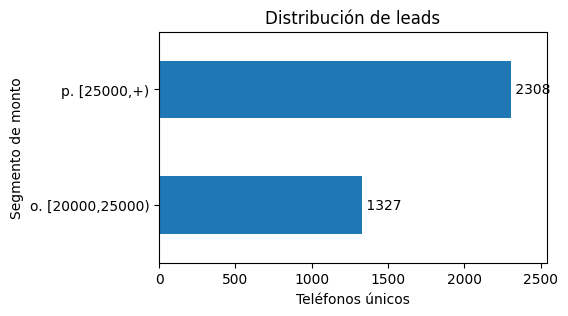

In [191]:
plt.figure(figsize=(5,3))  
import matplotlib.pyplot as plt

serie = df_muestra.groupby("seg_monto")["phone_number_02"] \
    .nunique() \
    .sort_index()

ax = serie.plot(kind="barh")

plt.xlabel("Teléfonos únicos")
plt.ylabel("Segmento de monto")
plt.title("Distribución de leads")
# 👇 espacio extra a la derecha
plt.xlim(0, serie.max() * 1.1)

# valores
for i, v in enumerate(serie.values):
    ax.text(v, i, f" {v}", va='center')

plt.show()

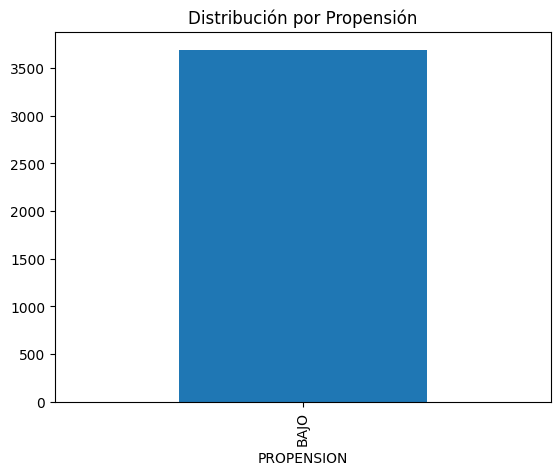

In [192]:
df_muestra["PROPENSION"].value_counts().plot(kind="bar")
plt.title("Distribución por Propensión")
plt.show()

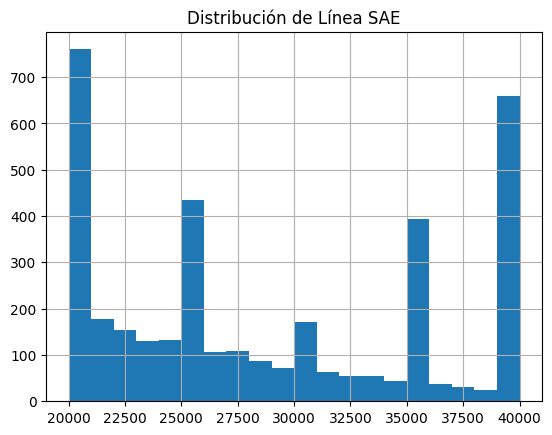

In [193]:
df_muestra["LINEA_SAE"].hist(bins=20)
plt.title("Distribución de Línea SAE")
plt.show()

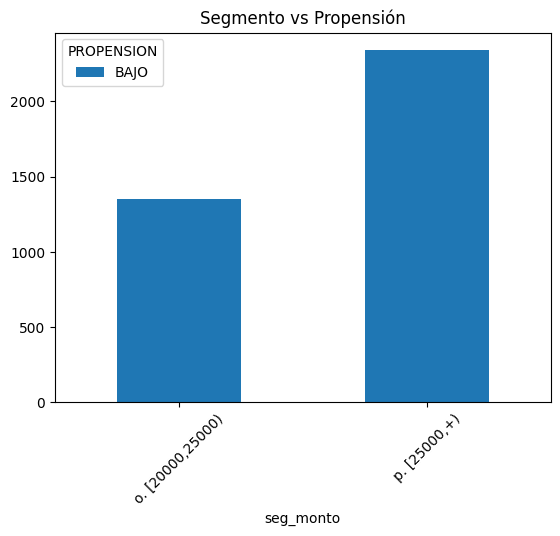

In [194]:
tabla = pd.crosstab(df_muestra["seg_monto"], df_muestra["PROPENSION"])

tabla.plot(kind="bar", stacked=True)
plt.title("Segmento vs Propensión")
plt.xticks(rotation=45)
plt.show()

In [183]:
df_dni=df_filtrado.select('vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments').orderBy(col('LINEA_SAE').desc()).toPandas()
# df_dni.to_csv(ruta_csv+'prueba.xlsx', index=False,sep=';')
import os

ruta_archivo = os.path.join(ruta_csv, 'sae_202603201548.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

TypeError: 'GroupedData' object is not subscriptable

<Figure size 500x300 with 0 Axes>

In [107]:
query = """
  SELECT * FROM cronox.dbo.borrar_df_cencosud_pp_01
    """
df_list_cencosud = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_list_cencosud = df_list_cencosud.withColumn(
    'LINEA_SAE',
    col('LINEA_SAE').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'q_intentos_telef',
    col('q_intentos_telef').cast('int')
)
df_list_cencosud = df_list_cencosud.withColumn(
    'tea',
    col('tea').cast('double')
)

# print(df_list_cencosud.columns)

# df_dni=df_list_cencosud.select('vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments').filter((col('fecha_envio')=='2026-03-20')&((col('fecha_llamada') != '2026-03-20')|(col('fecha_llamada').isNull())) &(col('tipo_telf').isin('bbdd cel01'))).orderBy(col('LINEA_SAE').desc()).toPandas()
df_dni.to_csv(ruta_csv+'prueba.xlsx', index=False,sep=';')
# df_list_cencosud.to_excel(ruta_csv+'prueba.xlsx', index=False)

In [22]:
['LAST NAME', 'FIRST NAME', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'TITLE', 'COMMENTS', 'SECURITY PHRASE', 'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'EMAIL', 'PHONE NUMBER', 'DEUDA', 'Tip_Prioridad', 'Zona', 'REGION', 'Perfil_ic', 'CANAL_ASIGNADO', 'MARCA', 'TIP_TELF', 'PROVEEDOR', 'Repitencia', 'Filtro', 'Cod_Tipi_Mejor_Gest', 'Cantidad_Sin_Discador', 'Cantidad_Discador', 'Recorrido_Hoy', 'Tipo_Telf', 'Fecha_Llam', 'Hora_Llamada', 'FECHA_ENVIO', 'RETIRO', 'Mejor_Estado_Telefono', 'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono', 'Mejor_Fecha_Telefono', 'Mejor_Duracion_Telefono', 'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente', 'Mejor_Descripcion_Cliente', 'Mejor_Fecha_Cliente', 'Mejor_Duracion_Cliente', 'Ultimo_Descripcion_Telefono', 'Ultimo_Fecha_Telefono', 'Ultima_Duracion_Telefono', 'Ultimo_Descripcion_Cli', 'Ultimo_Fecha_Cli', 'Ultima_Duracion_Cli', 'Veces_Cliente', 'prioridad', 'Veces_Telefono']

['LAST NAME', 'FIRST NAME', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'TITLE', 'COMMENTS', 'SECURITY PHRASE', 'VENDOR LEAD CODE', 'PROVINCE', 'CITY', 'EMAIL', 'PHONE NUMBER', 'DEUDA', 'Tip_Prioridad', 'Zona', 'REGION', 'Perfil_ic', 'CANAL_ASIGNADO', 'MARCA', 'TIP_TELF', 'PROVEEDOR', 'Repitencia', 'Filtro', 'Cod_Tipi_Mejor_Gest', 'Cantidad_Sin_Discador', 'Cantidad_Discador', 'Recorrido_Hoy', 'Tipo_Telf', 'Fecha_Llam', 'Hora_Llamada', 'FECHA_ENVIO', 'RETIRO', 'Mejor_Estado_Telefono', 'Mejor_Sub_Estado_Telefono', 'Mejor_Descripcion_Telefono', 'Mejor_Fecha_Telefono', 'Mejor_Duracion_Telefono', 'Mejor_Estado_Cliente', 'Mejor_Sub_Estado_Cliente', 'Mejor_Descripcion_Cliente', 'Mejor_Fecha_Cliente', 'Mejor_Duracion_Cliente', 'Ultimo_Descripcion_Telefono', 'Ultimo_Fecha_Telefono', 'Ultima_Duracion_Telefono', 'Ultimo_Descripcion_Cli', 'Ultimo_Fecha_Cli', 'Ultima_Duracion_Cli', 'Veces_Cliente', 'prioridad', 'Veces_Telefono']


['DNI TRUE', 'CLIENTE', 'TELEFONO']


1333

listo


1782

In [ ]:
df_filtrado.select('')

In [140]:
df_muestra=df_filtrado.toPandas()

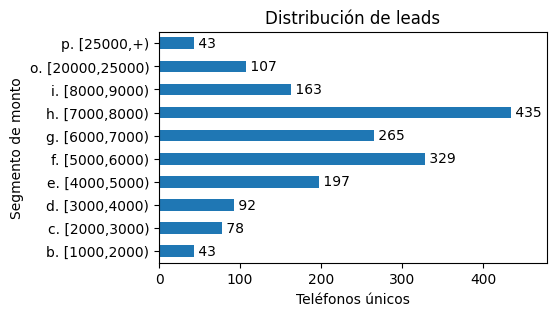

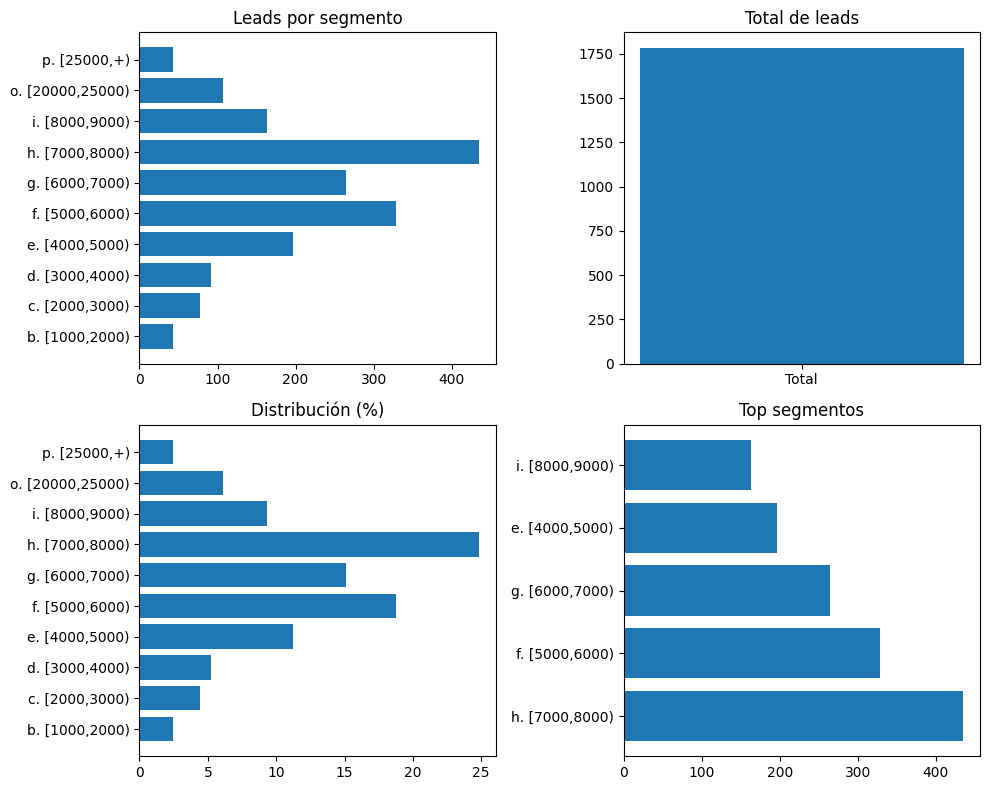

In [163]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# 🔹 1. Leads por segmento
serie = df_muestra.groupby("seg_monto")["phone_number_02"].nunique().sort_index()
axs[0,0].barh(serie.index, serie.values)
axs[0,0].set_title("Leads por segmento")

# 🔹 2. Total de registros
axs[0,1].bar(["Total"], [len(df_muestra)])
axs[0,1].set_title("Total de leads")

# 🔹 3. Distribución porcentual
porc = serie / serie.sum() * 100
axs[1,0].barh(porc.index, porc.values)
axs[1,0].set_title("Distribución (%)")

# 🔹 4. Top segmentos
top = serie.sort_values(ascending=False).head(5)
axs[1,1].barh(top.index, top.values)
axs[1,1].set_title("Top segmentos")

plt.tight_layout()
plt.show()

In [145]:
df_muestra[[ 'phone_number_02', 'seg_monto']].head()

,phone_number_02,seg_monto
0,924660411,"p. [25000,+)"
1,927365183,"p. [25000,+)"
2,991476615,"p. [25000,+)"
3,992446381,"p. [25000,+)"
4,994390783,"p. [25000,+)"


In [ ]:
df_muestra[['vendor_lead_code', 'phone_number_02', 'province', 'regimen_laboral', 'tea', 'EDAD', 'FRESCURA_TARGET', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'fecha_envio', 'tipo_base', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'fecha_gestion', 'promotor', 'estado_venta', 'tramo_venta', 'monto_venta', 'dni_ejecutivo_venta', 'producto_venta', 'cel_venta', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'dni_ejecutivo', 'ejecutivo', 'q_intentos_telef', 'mejor_CODIGO_cli', 'mejor_CODIGO_cli_dia', 'mejor15_CODIGO_cli', 'mejor15_CODIGO_telf', 'seg_monto', 'seg_tea', 'seg_edad', 'venta_validada', 'venta_sin_validar', 'venta_rechazada', 'venta_observada', 'q_venta']].head()

In [ ]:

df_dni=df_filtrado.select('vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments').filter((col('fecha_envio')=='2026-03-20')&((col('fecha_llamada') != '2026-03-20')|(col('fecha_llamada').isNull())) &(col('tipo_telf').isin('bbdd cel01'))).orderBy(col('LINEA_SAE').desc()).toPandas()
df_dni.to_csv(ruta_csv+'prueba.xlsx', index=False,sep=';')
df_list_cencosud.to_excel(ruta_csv+'prueba.xlsx', index=False)

In [103]:
# df_list_cencosud.filter(col('phone_number_02').isNotNull()).count()
df_list_cencosud.filter(col('phone_number').isNotNull()).count()

130510

+----------------+----------------------------+
|mejor_CODIGO_cli|mejor15_descripcion_cli     |
+----------------+----------------------------+
|R002            |ZONA FUERA DE COBERTURA     |
|R001            |CLIENTE ACEPTA PRODUCTO     |
|R012            |NO VOLVER A LLAMAR NUNCA MAS|
|R015            |CLIENTE FALLECIO            |
|R003            |VOLVER A LLAMAR             |
|R001            |NULL                        |
|R003            |NULL                        |
|R015            |NULL                        |
|R002            |NULL                        |
|R012            |NULL                        |
+----------------+----------------------------+



+----------------+----------------------------+
|mejor_CODIGO_cli|mejor15_descripcion_cli     |
+----------------+----------------------------+
|R002            |ZONA FUERA DE COBERTURA     |
|R001            |CLIENTE ACEPTA PRODUCTO     |
|R012            |NO VOLVER A LLAMAR NUNCA MAS|
|R015            |CLIENTE FALLECIO            |
|R003            |VOLVER A LLAMAR             |
|R001            |NULL                        |
|R003            |NULL                        |
|R015            |NULL                        |
|R002            |NULL                        |
|R012            |NULL                        |
+----------------+----------------------------+



In [98]:
df_list_cencosud.select('PROPENSION').distinct().show()

+----------+
|PROPENSION|
+----------+
|         7|
|      BAJO|
|         3|
|         8|
|     MEDIO|
|         5|
|         6|
|         1|
|         4|
|         2|
|      ALTO|
+----------+



In [21]:
lista = [row['title'] for row in df_list_cencosud.select('title').distinct().collect()]
print(lista)

['REC', 'SAE']


+----------------+----------------------------+
|mejor_CODIGO_cli|mejor_descripcion_cli       |
+----------------+----------------------------+
|R002            |ZONA FUERA DE COBERTURA     |
|R001            |CLIENTE ACEPTA PRODUCTO     |
|R012            |NO VOLVER A LLAMAR NUNCA MAS|
|R015            |CLIENTE FALLECIO            |
|R003            |VOLVER A LLAMAR             |
+----------------+----------------------------+



In [60]:
    
df_list_cencosud.select('vendor_lead_code', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments').filter((col('fecha_envio')=='2026-03-20')&((col('fecha_llamada') != '2026-03-20')|(col('fecha_llamada').isNull())) &(col('tipo_telf').isin('bbdd cel01'))).orderBy(col('LINEA_SAE').desc()).count()

2620

In [ ]:

df_dni=df_list_cencosud.filter(col('fecha_envio')=='2026-03-20').orderBy(col('LINEA_SAE').desc()).toPandas()
# df_dni.to_csv('lista_dni.csv', index=False,sep=';')
df_dni.to_excel(ruta_csv+'sae_202603201129.xlsx', index=False)

In [55]:
ruta_csv

'C:\\Users\\DATA\\Documents\\datos\\05_subir_csv'

In [ ]:
# df_dni.to_csv('lista_dni.csv', index=False,sep=';')
df_dni.to_excel(ruta_csv+'sae_202603201129.xlsx', index=False)

(123647, 92)

In [56]:
df_dni.to_excel(os.path.join(ruta_csv, 'sae_202603201129.xlsx'), index=False)

In [ ]:
cols_cat=['city','tipo_telf','province','tipo_base','PROPENSION','regimen_laboral','call_result','mejor15_estado_tipi_telf','mejor15_descripcion_telf']
cols_mum=['retiro_01','tea','LINEA_SAE','q_venta','mejor15_peso_telf','q_intentos_telef','PCT_SAE','tramo','orden_telf','duracion']


['vendor_lead_code', 'phone_number', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'tipo_telf', 'orden_telf', 'indice', 'regimen_laboral', 'producto', 'marca', 'tea', 'RETIRO', 'FEC_PAGO', 'FECHA_ULT_ATM', 'MONTO_ANT', 'FECHA_ULT_COMP', 'MONTO_DESEMBOLSAR', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'DISP_RETIRO_EFECT_', 'MEJORA_TASA', 'LINEA_SAE', 'PCT_SAE', 'ENTIDAD1', 'DEUDA1', 'ENTIDAD2', 'DEUDA2', 'ENTIDAD3', 'DEUDA3', 'EDAD', 'FRESCURA_TARGET', 'FLG_MEJORA', 'PROPENSION', 'TIPDOC', 'fecha_envio', 'tipo_base', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'fecha_gestion', 'promotor', 'estado_venta', 'tramo_venta', 'monto_venta', 'dni_ejecutivo_venta', 'producto_venta', 'cel_venta', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripci

tabla borrar_df_cencosud_pp_01 actualizada


24762

24762

In [19]:

df_prueba.count()


24727

In [ ]:
append_table_SQL(spark,df_prueba,'Base_Maestra_Cencosud_PPFF_01',server_kishin,user_kishin,pwd_kishin,'DANTALION')

In [2]:
ssss

NameError: name 'obtener_tabla_sql' is not defined

In [ ]:
sss

In [1]:
aa

NameError: name 'df_list_cencosud' is not defined

In [ ]:
a